[← Back to Overview](./00_overview.ipynb) | [← Previous: Clinical Analysis](./01_clinical_analysis.ipynb) | [Next: PAM50 Subtypes →](./03_pam50_subtype_analysis.ipynb)

# TCGA-BRCA Survival Data Analysis

Detailed analysis of survival outcomes including overall survival (OS), progression-free interval (PFI), disease-specific survival (DSS), and disease-free interval (DFI).

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Import XenaCohort for easy data loading
from oncolearn.api.xenabrowser import XenaCohortBuilder

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Build the cohort
builder = XenaCohortBuilder()
cohort = builder.build_cohort("BRCA")

## Load Survival Data

Using the `XenaCohort` class, we load clinical data which includes survival information.

In [2]:
# Load clinical data (includes survival data) using XenaCohort
clinical = cohort.clinical()

# Extract survival-specific columns
survival_cols = [col for col in clinical.columns if any(x in col for x in ['OS', 'PFI', 'DSS', 'DFI', 'survival', 'time', '_PATIENT'])]
survival = clinical[['sample'] + survival_cols].copy() if 'sample' in clinical.columns else clinical[survival_cols].copy()

# Remove duplicates based on sample
if 'sample' in survival.columns:
    survival = survival.drop_duplicates(subset='sample')

print(f"Survival data shape: {survival.shape}")
print(f"Number of samples: {len(survival)}")
print(f"\nSurvival-related columns: {survival_cols}")

survival.head(10)

Deduplicated brca/pam50: 141 -> 74 rows
Survival data shape: (1257, 8)
Number of samples: 1257

Survival-related columns: ['created_datetime.annotations', 'updated_datetime.annotations', 'created_datetime.treatments.diagnoses', 'updated_datetime.treatments.diagnoses', 'OS.time', 'OS', '_PATIENT']


,sample,created_datetime.annotations,updated_datetime.annotations,created_datetime.treatments.diagnoses,updated_datetime.treatments.diagnoses,OS.time,OS,_PATIENT
0,TCGA-3C-AAAU-01A,NaN,NaN,"['', '2019-04-28T13:35:03.916806-05:00']","['2019-07-31T21:21:01.590763-05:00', '2019-07-...",4047.0,0.0,TCGA-3C-AAAU
1,TCGA-3C-AALI-01A,NaN,NaN,"['2019-04-28T13:33:48.244636-05:00', '']","['2019-07-31T21:19:29.987911-05:00', '2019-07-...",4005.0,0.0,TCGA-3C-AALI
2,TCGA-3C-AALJ-01A,NaN,NaN,"['', '2019-04-28T08:37:49.629032-05:00']","['2019-07-31T15:17:14.528221-05:00', '2019-07-...",1474.0,0.0,TCGA-3C-AALJ
3,TCGA-3C-AALK-01A,NaN,NaN,"['2019-04-28T13:40:08.180007-05:00', '']","['2019-07-31T21:27:10.423927-05:00', '2019-07-...",1448.0,0.0,TCGA-3C-AALK
4,TCGA-4H-AAAK-01A,NaN,NaN,"['2019-04-28T08:37:04.368384-05:00', '']","['2019-07-31T15:16:22.301720-05:00', '2019-07-...",348.0,0.0,TCGA-4H-AAAK
5,TCGA-5L-AAT0-01A,NaN,NaN,"['', '2019-04-28T13:36:44.468306-05:00']","['2019-07-31T21:23:04.043540-05:00', '2019-07-...",1477.0,0.0,TCGA-5L-AAT0
6,TCGA-5L-AAT1-01A,2014-11-25T00:00:00,2018-08-23T16:36:27.780612-05:00,"['2019-04-28T13:30:41.595131-05:00', '']","['2019-07-31T21:15:47.269591-05:00', '2019-07-...",1471.0,0.0,TCGA-5L-AAT1
7,TCGA-5T-A9QA-01A,NaN,NaN,"['', '2019-04-28T13:31:51.876663-05:00']","['2019-07-31T21:17:13.416089-05:00', '2019-07-...",303.0,0.0,TCGA-5T-A9QA
8,TCGA-A1-A0SB-01A,NaN,NaN,"['', '2019-04-28T13:29:05.968748-05:00']","['2019-07-31T21:13:52.145227-05:00', '2019-07-...",259.0,0.0,TCGA-A1-A0SB
9,TCGA-A1-A0SD-01A,NaN,NaN,"['', '2019-04-28T13:40:12.888182-05:00']","['2019-07-31T21:27:16.149819-05:00', '2019-07-...",437.0,0.0,TCGA-A1-A0SD


In [3]:
# Data types and basic info
print("\nColumn Information:")
print(survival.dtypes)
print("\nMissing Data:")
for col in survival.columns:
    missing = survival[col].isna().sum()
    missing_pct = (missing / len(survival)) * 100
    print(f"{col:40s}: {missing:5d} ({missing_pct:5.1f}%)")


Column Information:
sample                                    object
created_datetime.annotations              object
updated_datetime.annotations              object
created_datetime.treatments.diagnoses     object
updated_datetime.treatments.diagnoses     object
OS.time                                  float64
OS                                       float64
_PATIENT                                  object
dtype: object

Missing Data:
sample                                  :     0 (  0.0%)
created_datetime.annotations            :  1224 ( 97.4%)
updated_datetime.annotations            :  1224 ( 97.4%)
created_datetime.treatments.diagnoses   :     3 (  0.2%)
updated_datetime.treatments.diagnoses   :     3 (  0.2%)
OS.time                                 :    25 (  2.0%)
OS                                      :    25 (  2.0%)
_PATIENT                                :    25 (  2.0%)


## Overall Survival (OS) Analysis

In [4]:
# OS columns
os_cols = [col for col in survival.columns if 'OS' in col]
print(f"Overall Survival columns: {os_cols}")

if len(os_cols) >= 2:
    # Typically OS (event) and OS.time
    os_event_col = [c for c in os_cols if c == 'OS' or 'event' in c.lower()][0] if any(
        'OS' in c or 'event' in c.lower() for c in os_cols) else os_cols[0]
    os_time_col = [c for c in os_cols if 'time' in c.lower()][0] if any(
        'time' in c.lower() for c in os_cols) else os_cols[1]

    print(f"\nEvent column: {os_event_col}")
    print(f"Time column: {os_time_col}")

    # Event distribution
    print(f"\nOS Event Distribution:")
    print(survival[os_event_col].value_counts())

    # Time statistics
    os_time = pd.to_numeric(survival[os_time_col], errors='coerce')
    print(f"\nOS Time Statistics (days):")
    print(os_time.describe())
    print(
        f"\nIn years: Min={os_time.min()/365.25:.1f}, Max={os_time.max()/365.25:.1f}, Median={os_time.median()/365.25:.1f}")

Overall Survival columns: ['OS.time', 'OS']

Event column: OS
Time column: OS.time

OS Event Distribution:
OS
0.0    1031
1.0     201
Name: count, dtype: int64

OS Time Statistics (days):
count    1232.00000
mean     1273.17776
std      1154.55418
min         1.00000
25%       486.50000
50%       922.00000
75%      1734.50000
max      8605.00000
Name: OS.time, dtype: float64

In years: Min=0.0, Max=23.6, Median=2.5


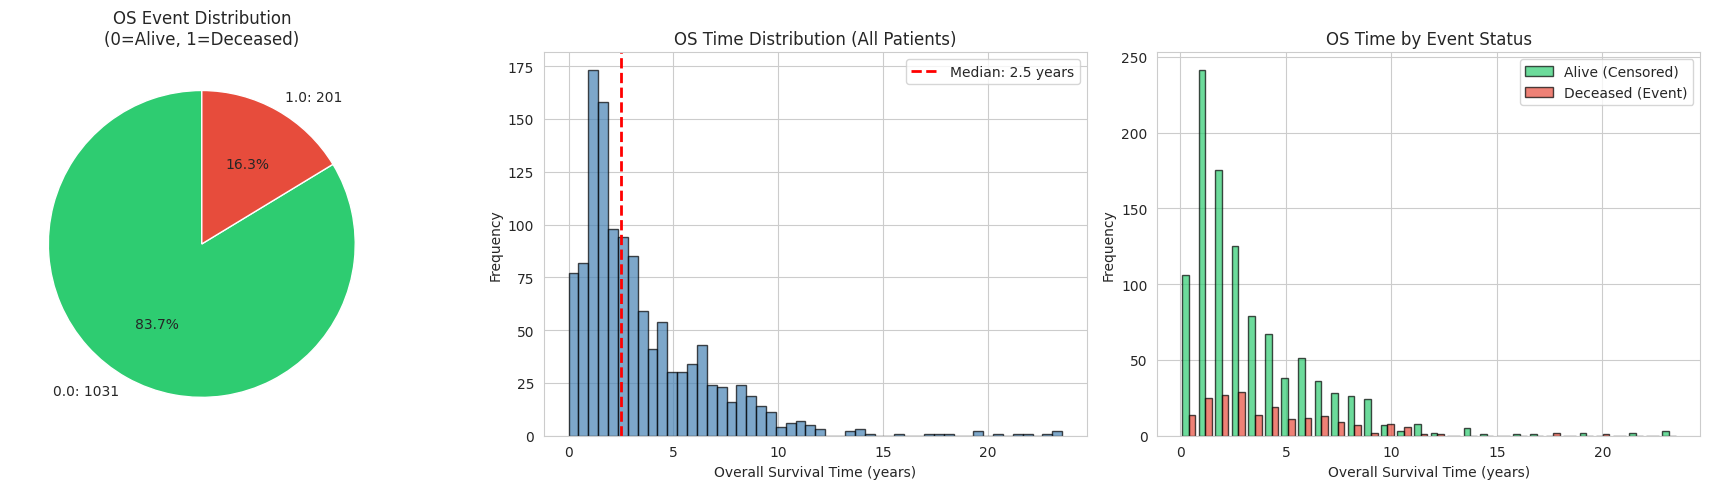


Alive patients - Median follow-up: 2.3 years
Deceased patients - Median survival: 3.5 years


In [5]:
# Visualize OS
if len(os_cols) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Event distribution
    event_counts = survival[os_event_col].value_counts()
    colors = ['#2ecc71', '#e74c3c'] if len(event_counts) == 2 else None
    axes[0].pie(event_counts.values, labels=[f'{idx}: {val}' for idx, val in zip(event_counts.index, event_counts.values)],
                autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title(f'OS Event Distribution\n(0=Alive, 1=Deceased)')

    # Time distribution - all patients
    os_time_clean = os_time.dropna()
    axes[1].hist(os_time_clean / 365.25, bins=50,
                 color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].axvline(os_time_clean.median() / 365.25, color='red', linestyle='--', linewidth=2,
                    label=f'Median: {os_time_clean.median()/365.25:.1f} years')
    axes[1].set_xlabel('Overall Survival Time (years)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('OS Time Distribution (All Patients)')
    axes[1].legend()

    # Time distribution by event status
    os_event_clean = pd.to_numeric(survival[os_event_col], errors='coerce')
    alive_time = os_time[os_event_clean == 0].dropna() / 365.25
    deceased_time = os_time[os_event_clean == 1].dropna() / 365.25

    axes[2].hist([alive_time, deceased_time], bins=30, label=['Alive (Censored)', 'Deceased (Event)'],
                 color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[2].set_xlabel('Overall Survival Time (years)')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('OS Time by Event Status')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print(
        f"\nAlive patients - Median follow-up: {alive_time.median():.1f} years")
    print(
        f"Deceased patients - Median survival: {deceased_time.median():.1f} years")

## Progression-Free Interval (PFI) Analysis

In [6]:
# PFI columns
pfi_cols = [col for col in survival.columns if 'PFI' in col]
print(f"Progression-Free Interval columns: {pfi_cols}")

if len(pfi_cols) >= 2:
    pfi_event_col = [c for c in pfi_cols if c == 'PFI' or 'event' in c.lower()][0] if any(
        'PFI' in c or 'event' in c.lower() for c in pfi_cols) else pfi_cols[0]
    pfi_time_col = [c for c in pfi_cols if 'time' in c.lower()][0] if any(
        'time' in c.lower() for c in pfi_cols) else pfi_cols[1]

    print(f"\nPFI Event Distribution:")
    print(survival[pfi_event_col].value_counts())

    pfi_time = pd.to_numeric(survival[pfi_time_col], errors='coerce')
    print(f"\nPFI Time Statistics (days):")
    print(pfi_time.describe())
    print(
        f"\nIn years: Min={pfi_time.min()/365.25:.1f}, Max={pfi_time.max()/365.25:.1f}, Median={pfi_time.median()/365.25:.1f}")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Event distribution
    event_counts = survival[pfi_event_col].value_counts()
    axes[0].pie(event_counts.values, labels=[f'{idx}: {val}' for idx, val in zip(event_counts.index, event_counts.values)],
                autopct='%1.1f%%', colors=['#3498db', '#e67e22'], startangle=90)
    axes[0].set_title(
        'PFI Event Distribution\n(0=No Progression, 1=Progression)')

    # Time distribution
    pfi_time_clean = pfi_time.dropna()
    axes[1].hist(pfi_time_clean / 365.25, bins=50,
                 color='#9b59b6', alpha=0.7, edgecolor='black')
    axes[1].axvline(pfi_time_clean.median() / 365.25, color='red', linestyle='--', linewidth=2,
                    label=f'Median: {pfi_time_clean.median()/365.25:.1f} years')
    axes[1].set_xlabel('Progression-Free Interval (years)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('PFI Time Distribution')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Progression-Free Interval columns: []


## Disease-Specific Survival (DSS) Analysis

In [7]:
# DSS columns
dss_cols = [col for col in survival.columns if 'DSS' in col]
print(f"Disease-Specific Survival columns: {dss_cols}")

if len(dss_cols) >= 2:
    dss_event_col = [c for c in dss_cols if c == 'DSS' or 'event' in c.lower()][0] if any(
        'DSS' in c or 'event' in c.lower() for c in dss_cols) else dss_cols[0]
    dss_time_col = [c for c in dss_cols if 'time' in c.lower()][0] if any(
        'time' in c.lower() for c in dss_cols) else dss_cols[1]

    print(f"\nDSS Event Distribution:")
    print(survival[dss_event_col].value_counts())

    dss_time = pd.to_numeric(survival[dss_time_col], errors='coerce')
    print(f"\nDSS Time Statistics (days):")
    print(dss_time.describe())

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    event_counts = survival[dss_event_col].value_counts()
    axes[0].pie(event_counts.values, labels=[f'{idx}: {val}' for idx, val in zip(event_counts.index, event_counts.values)],
                autopct='%1.1f%%', colors=['#1abc9c', '#c0392b'], startangle=90)
    axes[0].set_title(
        'DSS Event Distribution\n(0=Alive/Other Death, 1=Disease Death)')

    dss_time_clean = dss_time.dropna()
    axes[1].hist(dss_time_clean / 365.25, bins=50,
                 color='#16a085', alpha=0.7, edgecolor='black')
    axes[1].axvline(dss_time_clean.median() / 365.25, color='red', linestyle='--', linewidth=2,
                    label=f'Median: {dss_time_clean.median()/365.25:.1f} years')
    axes[1].set_xlabel('Disease-Specific Survival (years)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('DSS Time Distribution')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Disease-Specific Survival columns: []


## Disease-Free Interval (DFI) Analysis

In [8]:
# DFI columns
dfi_cols = [col for col in survival.columns if 'DFI' in col]
print(f"Disease-Free Interval columns: {dfi_cols}")

if len(dfi_cols) >= 2:
    dfi_event_col = [c for c in dfi_cols if c == 'DFI' or 'event' in c.lower()][0] if any(
        'DFI' in c or 'event' in c.lower() for c in dfi_cols) else dfi_cols[0]
    dfi_time_col = [c for c in dfi_cols if 'time' in c.lower()][0] if any(
        'time' in c.lower() for c in dfi_cols) else dfi_cols[1]

    print(f"\nDFI Event Distribution:")
    print(survival[dfi_event_col].value_counts())

    dfi_time = pd.to_numeric(survival[dfi_time_col], errors='coerce')
    print(f"\nDFI Time Statistics (days):")
    print(dfi_time.describe())

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    event_counts = survival[dfi_event_col].value_counts()
    axes[0].pie(event_counts.values, labels=[f'{idx}: {val}' for idx, val in zip(event_counts.index, event_counts.values)],
                autopct='%1.1f%%', colors=['#3498db', '#e67e22'], startangle=90)
    axes[0].set_title('DFI Event Distribution\n(0=Disease-Free, 1=Recurrence)')

    dfi_time_clean = dfi_time.dropna()
    axes[1].hist(dfi_time_clean / 365.25, bins=50,
                 color='#f39c12', alpha=0.7, edgecolor='black')
    axes[1].axvline(dfi_time_clean.median() / 365.25, color='red', linestyle='--', linewidth=2,
                    label=f'Median: {dfi_time_clean.median()/365.25:.1f} years')
    axes[1].set_xlabel('Disease-Free Interval (years)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('DFI Time Distribution')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Disease-Free Interval columns: []


## Comparison of Survival Endpoints

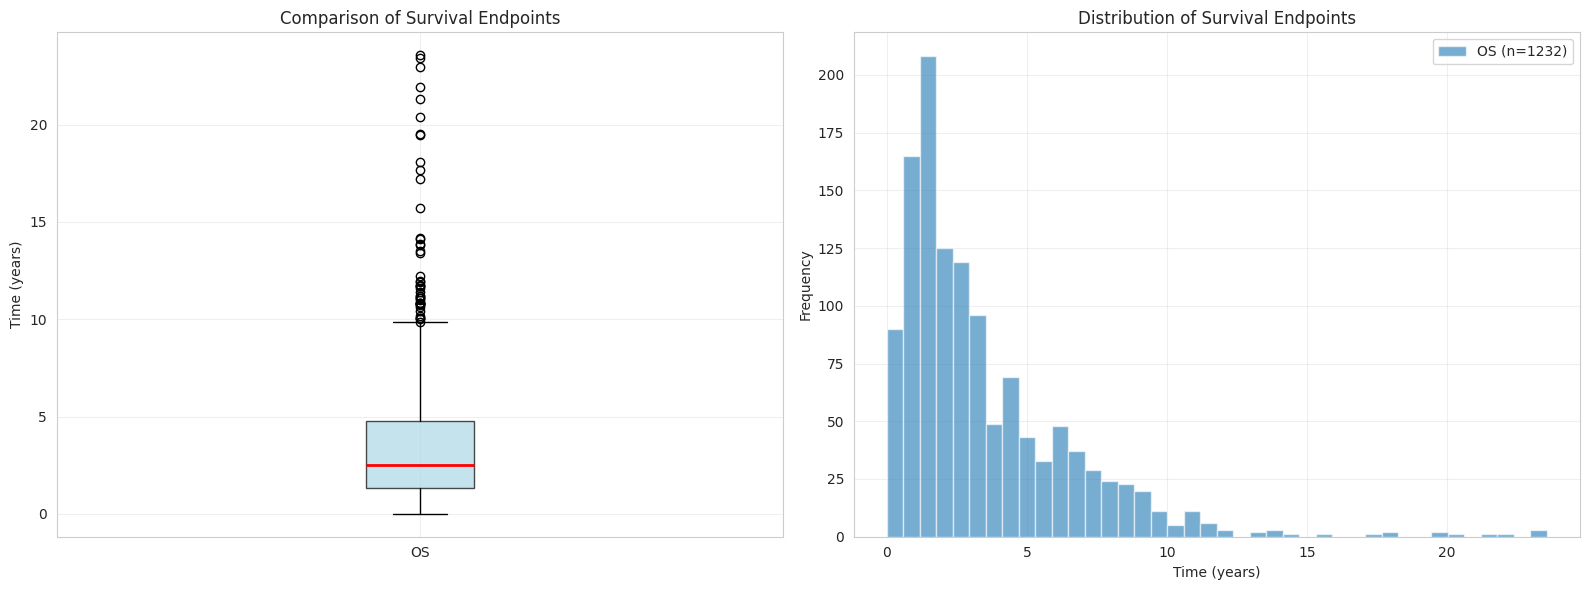


Summary Statistics (years):
Endpoint    N Mean Median  Std  Min   Max
      OS 1232 3.49   2.52 3.16 0.00 23.56


In [9]:
# Compare all survival times
survival_types = []
survival_times = []
survival_labels = []

if len(os_cols) >= 2:
    os_time_clean = pd.to_numeric(
        survival[os_time_col], errors='coerce').dropna() / 365.25
    survival_types.append('OS')
    survival_times.append(os_time_clean)
    survival_labels.append(f'OS (n={len(os_time_clean)})')

if len(pfi_cols) >= 2:
    pfi_time_clean = pd.to_numeric(
        survival[pfi_time_col], errors='coerce').dropna() / 365.25
    survival_types.append('PFI')
    survival_times.append(pfi_time_clean)
    survival_labels.append(f'PFI (n={len(pfi_time_clean)})')

if len(dss_cols) >= 2:
    dss_time_clean = pd.to_numeric(
        survival[dss_time_col], errors='coerce').dropna() / 365.25
    survival_types.append('DSS')
    survival_times.append(dss_time_clean)
    survival_labels.append(f'DSS (n={len(dss_time_clean)})')

if len(dfi_cols) >= 2:
    dfi_time_clean = pd.to_numeric(
        survival[dfi_time_col], errors='coerce').dropna() / 365.25
    survival_types.append('DFI')
    survival_times.append(dfi_time_clean)
    survival_labels.append(f'DFI (n={len(dfi_time_clean)})')

if len(survival_times) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Box plots
    axes[0].boxplot(survival_times, labels=survival_types, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[0].set_ylabel('Time (years)')
    axes[0].set_title('Comparison of Survival Endpoints')
    axes[0].grid(True, alpha=0.3)

    # Overlaid histograms
    axes[1].hist(survival_times, bins=40, label=survival_labels, alpha=0.6)
    axes[1].set_xlabel('Time (years)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Survival Endpoints')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print("\nSummary Statistics (years):")
    summary_data = []
    for stype, stime in zip(survival_types, survival_times):
        summary_data.append({
            'Endpoint': stype,
            'N': len(stime),
            'Mean': f"{stime.mean():.2f}",
            'Median': f"{stime.median():.2f}",
            'Std': f"{stime.std():.2f}",
            'Min': f"{stime.min():.2f}",
            'Max': f"{stime.max():.2f}"
        })
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

## Event Rate Summary


Event Rate Summary:
Endpoint  Events  Total Event Rate (%)
      OS     201   1232           16.3


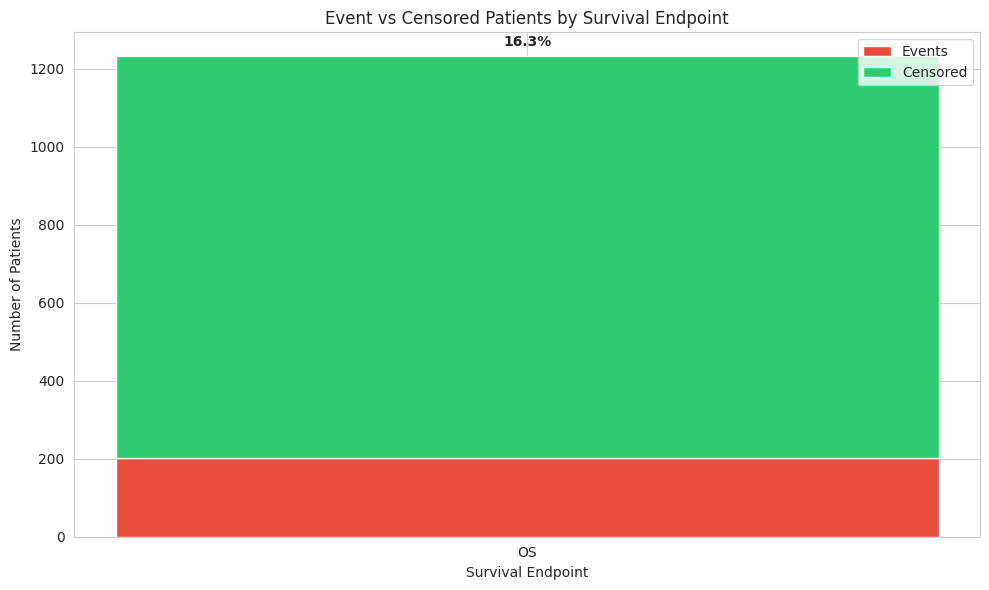

In [10]:
# Calculate event rates
event_summary = []

if len(os_cols) >= 2:
    os_events = pd.to_numeric(survival[os_event_col], errors='coerce')
    event_rate = (os_events.sum() / os_events.count()) * 100
    event_summary.append({'Endpoint': 'OS', 'Events': int(os_events.sum()),
                         'Total': int(os_events.count()), 'Event Rate (%)': f"{event_rate:.1f}"})

if len(pfi_cols) >= 2:
    pfi_events = pd.to_numeric(survival[pfi_event_col], errors='coerce')
    event_rate = (pfi_events.sum() / pfi_events.count()) * 100
    event_summary.append({'Endpoint': 'PFI', 'Events': int(pfi_events.sum()),
                         'Total': int(pfi_events.count()), 'Event Rate (%)': f"{event_rate:.1f}"})

if len(dss_cols) >= 2:
    dss_events = pd.to_numeric(survival[dss_event_col], errors='coerce')
    event_rate = (dss_events.sum() / dss_events.count()) * 100
    event_summary.append({'Endpoint': 'DSS', 'Events': int(dss_events.sum()),
                         'Total': int(dss_events.count()), 'Event Rate (%)': f"{event_rate:.1f}"})

if len(dfi_cols) >= 2:
    dfi_events = pd.to_numeric(survival[dfi_event_col], errors='coerce')
    event_rate = (dfi_events.sum() / dfi_events.count()) * 100
    event_summary.append({'Endpoint': 'DFI', 'Events': int(dfi_events.sum()),
                         'Total': int(dfi_events.count()), 'Event Rate (%)': f"{event_rate:.1f}"})

if event_summary:
    event_df = pd.DataFrame(event_summary)
    print("\nEvent Rate Summary:")
    print(event_df.to_string(index=False))

    # Visualize event rates
    plt.figure(figsize=(10, 6))
    endpoints = [e['Endpoint'] for e in event_summary]
    events = [e['Events'] for e in event_summary]
    totals = [e['Total'] for e in event_summary]
    censored = [t - e for t, e in zip(totals, events)]

    x = np.arange(len(endpoints))
    width = 0.6

    p1 = plt.bar(x, events, width, label='Events', color='#e74c3c')
    p2 = plt.bar(x, censored, width, bottom=events,
                 label='Censored', color='#2ecc71')

    plt.xlabel('Survival Endpoint')
    plt.ylabel('Number of Patients')
    plt.title('Event vs Censored Patients by Survival Endpoint')
    plt.xticks(x, endpoints)
    plt.legend()

    # Add percentage labels
    for i, (e, t) in enumerate(zip(events, totals)):
        pct = (e / t) * 100
        plt.text(i, t + 20, f'{pct:.1f}%', ha='center',
                 va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

## Summary

In [11]:
print("\n" + "="*60)
print("TCGA-BRCA Survival Data Summary")
print("="*60)
print(f"Total samples: {len(survival)}")
print(
    f"Survival endpoints available: {len(survival_types) if 'survival_types' in locals() else 'Unknown'}")
print("="*60)


TCGA-BRCA Survival Data Summary
Total samples: 1257
Survival endpoints available: 1
